# 02. EDA: связи признаков и таргета

**Цель:** анализ признаков.

- Распределение (гистограммы и boxplot) 
- Корреляции каждого признака с бинарным `target` 
- Межпризнаковые корреляции (поиск кластеров взаимозависящих фичей)
- scatter-plots топ признраков

Понять структуру данных, мультиколлинеарность, информативность группы признаков.

In [4]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ------- Пути -------
try:
    NB_DIR = Path(__file__).resolve().parent
except NameError:
    NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR

FIG_DIR   = PROJECT_ROOT / "results" / "figures"
TAB_DIR   = PROJECT_ROOT / "results" / "tables"
CACHE_DIR = PROJECT_ROOT / "cache"
for p in (FIG_DIR, TAB_DIR):
    p.mkdir(parents=True, exist_ok=True)

LABEL_COL = "label"
BENIGN_LABEL = "BENIGN"

# ------- Изучаемые и отобранные признаки -------
MODEL_FEATURES: list[str] = [
    "protocol",

    "src2dst_packets",
    "dst2src_packets",
    "src2dst_bytes",
    "dst2src_bytes",

    "bidirectional_duration_ms",

    "bidirectional_min_ps",
    "bidirectional_max_ps",
    "bidirectional_mean_ps",
    "bidirectional_stddev_ps",

    "src2dst_max_ps",
    "src2dst_min_ps",
    "src2dst_mean_ps",
    "src2dst_stddev_ps",

    "dst2src_max_ps",
    "dst2src_min_ps",
    "dst2src_mean_ps",
    "dst2src_stddev_ps",

    "bidirectional_mean_piat_ms",
    "bidirectional_stddev_piat_ms",
    "bidirectional_max_piat_ms",
    "bidirectional_min_piat_ms",

    "src2dst_mean_piat_ms",
    "src2dst_stddev_piat_ms",
    "src2dst_max_piat_ms",
    "src2dst_min_piat_ms",

    "dst2src_mean_piat_ms",
    "dst2src_stddev_piat_ms",
    "dst2src_max_piat_ms",
    "dst2src_min_piat_ms",

    "bidirectional_fin_packets",
    "bidirectional_syn_packets",
    "bidirectional_rst_packets",
    "bidirectional_psh_packets",
    "bidirectional_ack_packets",
    "bidirectional_urg_packets",
    "bidirectional_cwr_packets",
    "bidirectional_ece_packets",

    "src2dst_psh_packets",
    "dst2src_psh_packets",
    "src2dst_urg_packets",
    "dst2src_urg_packets",
]

print(f"MODEL_FEATURES: {len(MODEL_FEATURES)} признаков")

MODEL_FEATURES: 42 признаков


In [6]:
CACHE_PARQUET = CACHE_DIR / "nfs_2023_nte_all.parquet"
df = pd.read_parquet(CACHE_PARQUET)
df["target"] = (
    df[LABEL_COL].astype(str).str.strip().str.upper() != BENIGN_LABEL
).astype(np.int64)

missing = [c for c in MODEL_FEATURES if c not in df.columns]

print(f"shape: {df.shape}")
print(f"BENIGN: {(df['target'] == 0).sum():,}, ANOMALY: {(df['target'] == 1).sum():,}")

shape: (2111131, 79)
BENIGN: 1,612,267, ANOMALY: 498,864


## 0. Группы признаков

Для визуализации 42 признака делятся на 5 групп по смыслу:
1) **PS** (packet sizes) - `*_min_ps`, `*_mean_ps`, `*_stddev_ps`, `*_max_ps`
    во всех трех направлениях

2) **PIAT** (packet inter-arrival times, 12) — то же, но временные интервалы.

3) **FLAGS** (8) — счетчики TCP-флагов в bidirectional.

4) **COUNTERS** (7) — `bidirectional_duration_ms`, `*_packets`, `*_bytes`
  во всех направлениях.

5) **META** (1) — `protocol`.

In [7]:
FEAT_PS    = [c for c in MODEL_FEATURES if c.endswith(("_min_ps", "_mean_ps",
                                                       "_stddev_ps", "_max_ps"))]
FEAT_PIAT  = [c for c in MODEL_FEATURES if c.endswith(("_min_piat_ms", "_mean_piat_ms",
                                                       "_stddev_piat_ms", "_max_piat_ms"))]
FEAT_FLAGS = [c for c in MODEL_FEATURES if c.endswith(("_syn_packets", "_cwr_packets",
                                                       "_ece_packets", "_urg_packets",
                                                       "_ack_packets", "_psh_packets",
                                                       "_rst_packets", "_fin_packets"))]
FEAT_COUNT = [c for c in MODEL_FEATURES
              if c in ("bidirectional_duration_ms",
                       "bidirectional_packets", "bidirectional_bytes",
                       "src2dst_packets", "src2dst_bytes",
                       "dst2src_packets", "dst2src_bytes")]
FEAT_META  = ["protocol"]

GROUPS = {
    "PS":       FEAT_PS,
    "PIAT":     FEAT_PIAT,
    "FLAGS":    FEAT_FLAGS,
    "COUNTERS": FEAT_COUNT,
    "META":     FEAT_META,
}
for name, lst in GROUPS.items():
    print(f"{name:10s} {len(lst):>2d}  {lst}")

assert sum(len(v) for v in GROUPS.values()) == 42

PS         12  ['bidirectional_min_ps', 'bidirectional_max_ps', 'bidirectional_mean_ps', 'bidirectional_stddev_ps', 'src2dst_max_ps', 'src2dst_min_ps', 'src2dst_mean_ps', 'src2dst_stddev_ps', 'dst2src_max_ps', 'dst2src_min_ps', 'dst2src_mean_ps', 'dst2src_stddev_ps']
PIAT       12  ['bidirectional_mean_piat_ms', 'bidirectional_stddev_piat_ms', 'bidirectional_max_piat_ms', 'bidirectional_min_piat_ms', 'src2dst_mean_piat_ms', 'src2dst_stddev_piat_ms', 'src2dst_max_piat_ms', 'src2dst_min_piat_ms', 'dst2src_mean_piat_ms', 'dst2src_stddev_piat_ms', 'dst2src_max_piat_ms', 'dst2src_min_piat_ms']
FLAGS      12  ['bidirectional_fin_packets', 'bidirectional_syn_packets', 'bidirectional_rst_packets', 'bidirectional_psh_packets', 'bidirectional_ack_packets', 'bidirectional_urg_packets', 'bidirectional_cwr_packets', 'bidirectional_ece_packets', 'src2dst_psh_packets', 'dst2src_psh_packets', 'src2dst_urg_packets', 'dst2src_urg_packets']
COUNTERS    5  ['src2dst_packets', 'dst2src_packets', 'src2dst_b

## 1. Гистограммы по группам

- Для PS / PIAT / COUNTERS - используется масштаб `log1p`, для читаемости

- Цветовое кодирование:
    - `BENIGN` - синий
    - `ANOMALY` - оранжевый

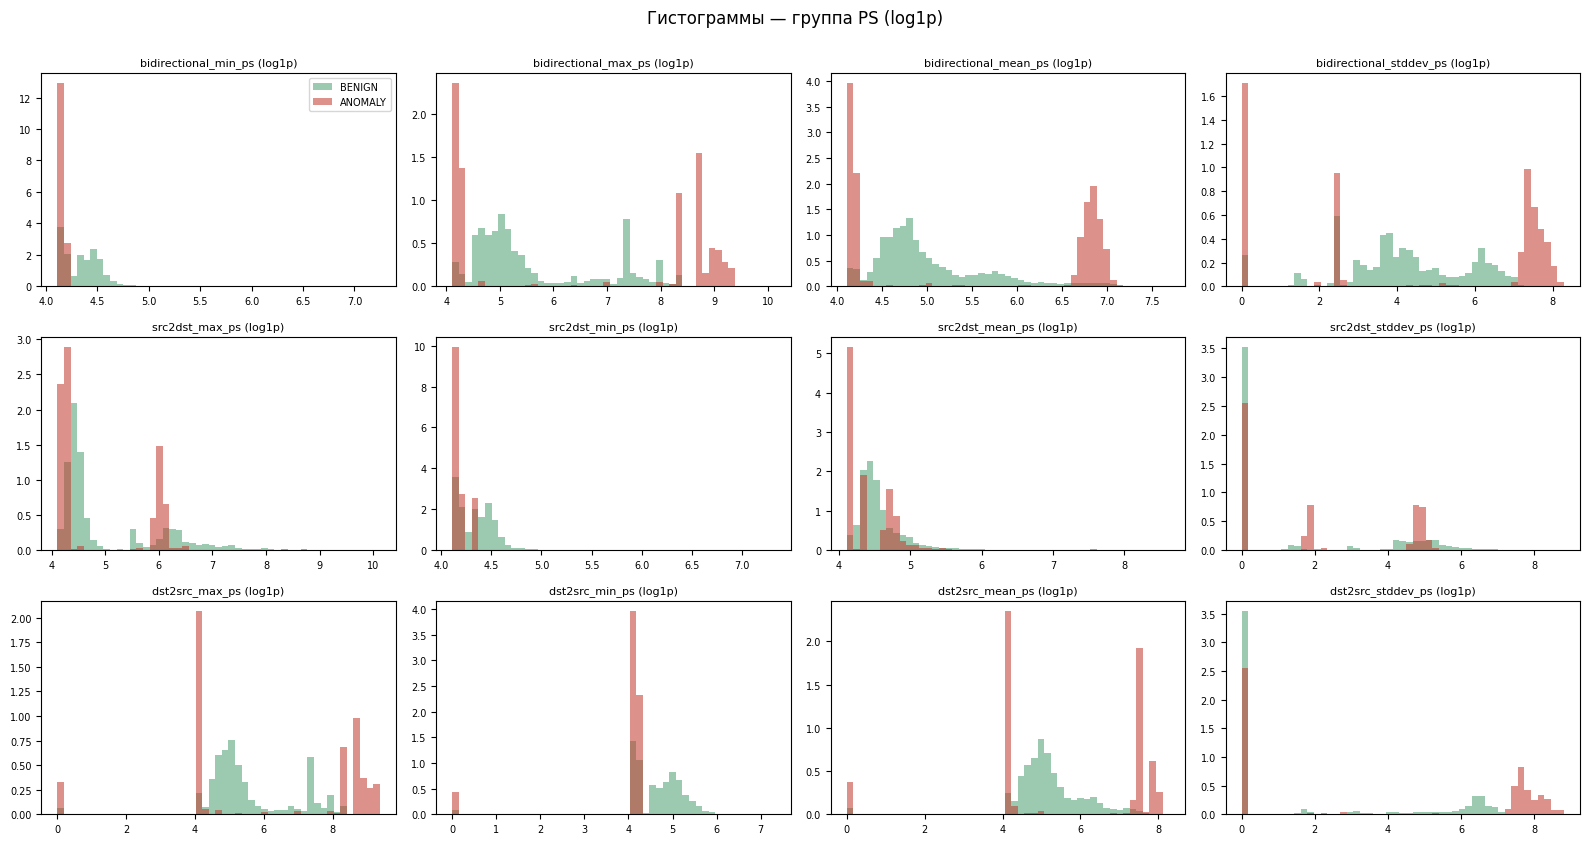

Saved: /workspace/results/figures/fig_02_hist_ps.png


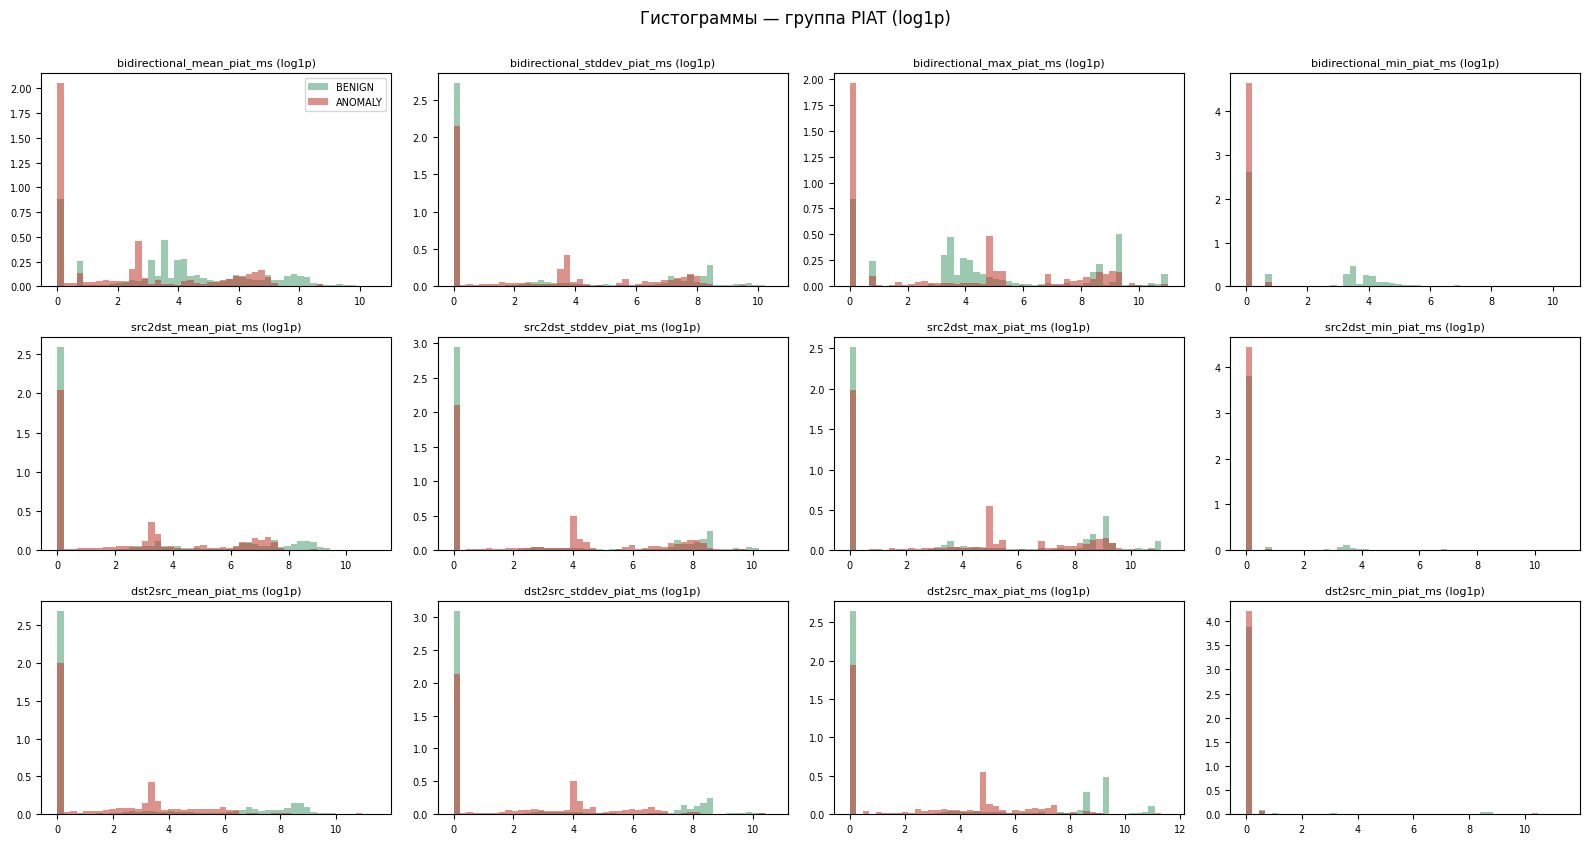

Saved: /workspace/results/figures/fig_02_hist_piat.png


/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:902: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:902: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


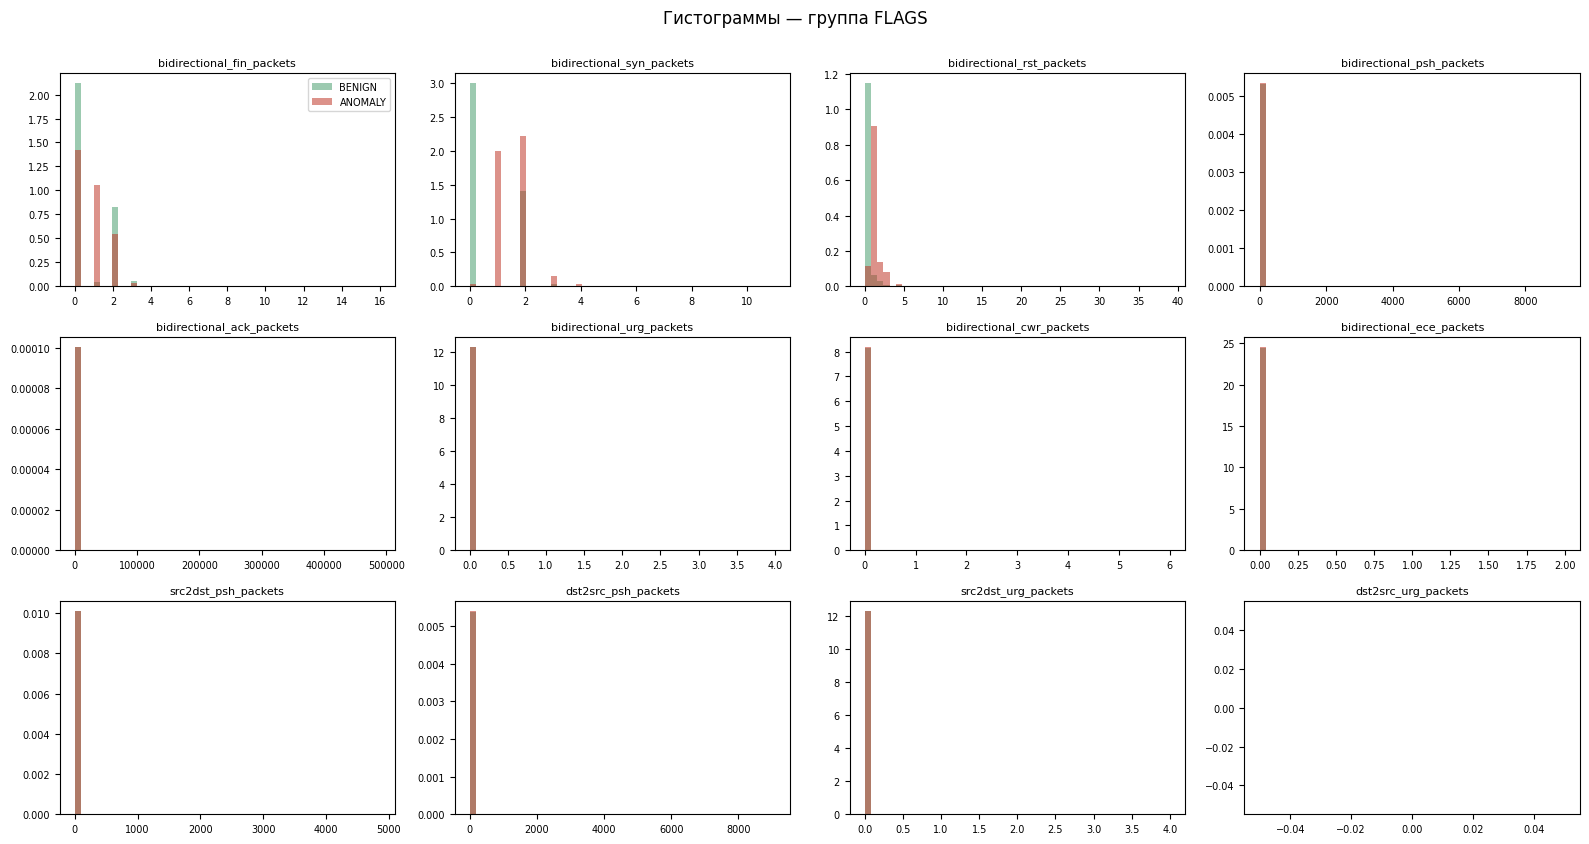

Saved: /workspace/results/figures/fig_02_hist_flags.png


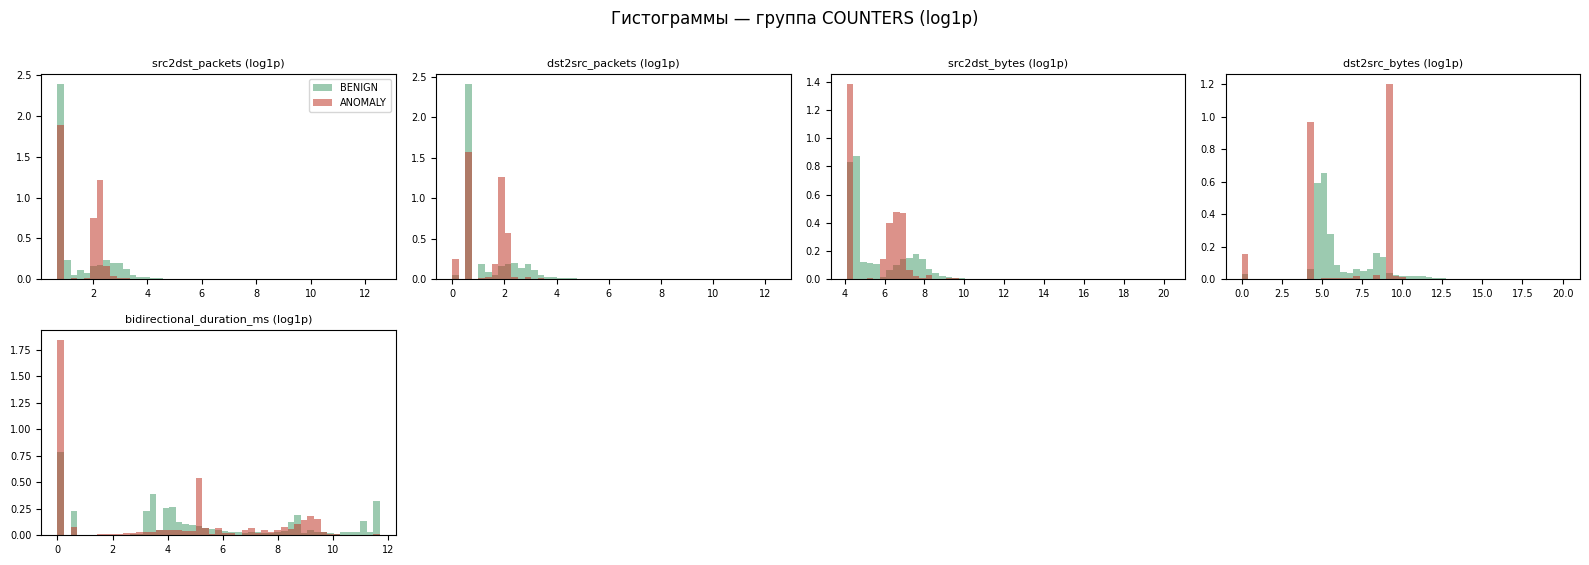

Saved: /workspace/results/figures/fig_02_hist_counters.png


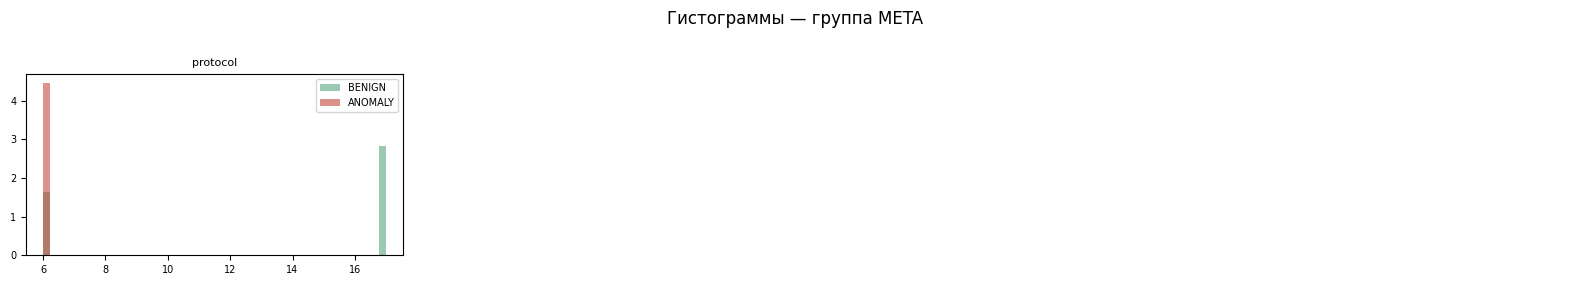

Saved: /workspace/results/figures/fig_02_hist_meta.png


In [8]:
def plot_hist_group(df: pd.DataFrame, features: list[str],
                    group_name: str, use_log1p: bool,
                    sample_size: int = 200_000) -> None:
    n = len(features)
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.8 * nrows))
    axes = np.atleast_2d(axes).ravel()

    rng = np.random.default_rng(RANDOM_STATE)
    n_per_class = sample_size // 2
    benign_idx = df.index[df["target"] == 0]
    anom_idx   = df.index[df["target"] == 1]
    benign_sample = rng.choice(benign_idx, size=min(n_per_class, len(benign_idx)),
                               replace=False)
    anom_sample   = rng.choice(anom_idx,   size=min(n_per_class, len(anom_idx)),
                               replace=False)

    for i, col in enumerate(features):
        ax = axes[i]
        x0 = df.loc[benign_sample, col].astype("float64").to_numpy()
        x1 = df.loc[anom_sample,   col].astype("float64").to_numpy()
        if use_log1p:
            x0 = np.log1p(np.clip(x0, 0, None))
            x1 = np.log1p(np.clip(x1, 0, None))
        # общие бины по объединенному диапазону
        bins = np.linspace(min(x0.min(), x1.min()), max(x0.max(), x1.max()), 50)
        ax.hist(x0, bins=bins, alpha=0.55, label="BENIGN",  color="#4C9F70", density=True)
        ax.hist(x1, bins=bins, alpha=0.55, label="ANOMALY", color="#C0392B", density=True)
        title = col + (" (log1p)" if use_log1p else "")
        ax.set_title(title, fontsize=8)
        ax.tick_params(labelsize=7)
        if i == 0:
            ax.legend(fontsize=7)

    # пустые subplot
    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Гистограммы — группа {group_name}"
                 f"{' (log1p)' if use_log1p else ''}",
                 fontsize=12, y=1.00)
    plt.tight_layout()
    out = FIG_DIR / f"fig_02_hist_{group_name.lower()}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

plot_hist_group(df, FEAT_PS,    "PS",       use_log1p=True)
plot_hist_group(df, FEAT_PIAT,  "PIAT",     use_log1p=True)
plot_hist_group(df, FEAT_FLAGS, "FLAGS",    use_log1p=False)
plot_hist_group(df, FEAT_COUNT, "COUNTERS", use_log1p=True)
plot_hist_group(df, FEAT_META,  "META",     use_log1p=False)

## 2. Boxplot в разрезе target

Для каждой группы строится boxplot с разбиением по target.

Это дает представление, видны медиана, IQR, размах.

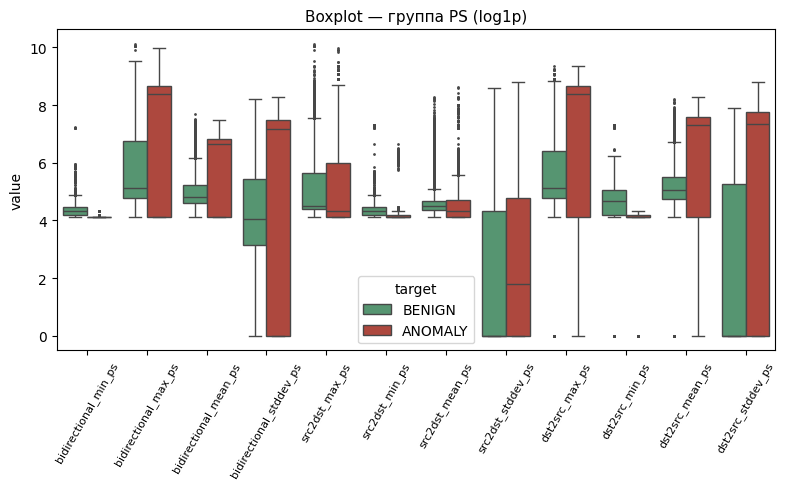

Saved: /workspace/results/figures/fig_02_boxplot_ps.png


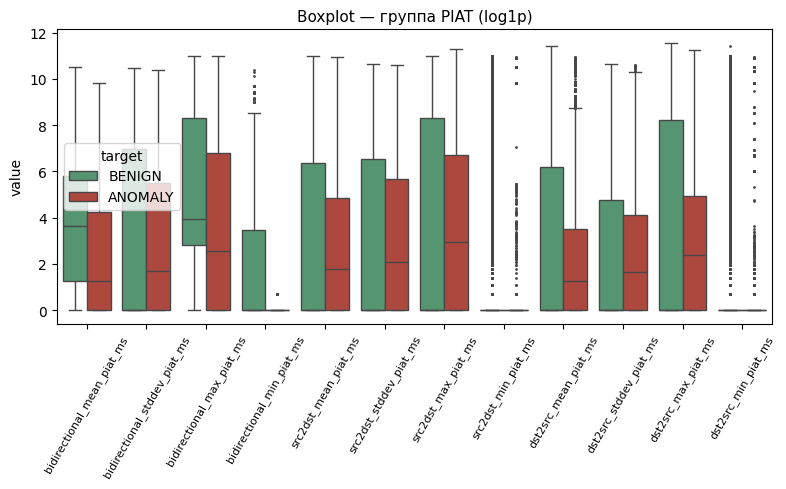

Saved: /workspace/results/figures/fig_02_boxplot_piat.png


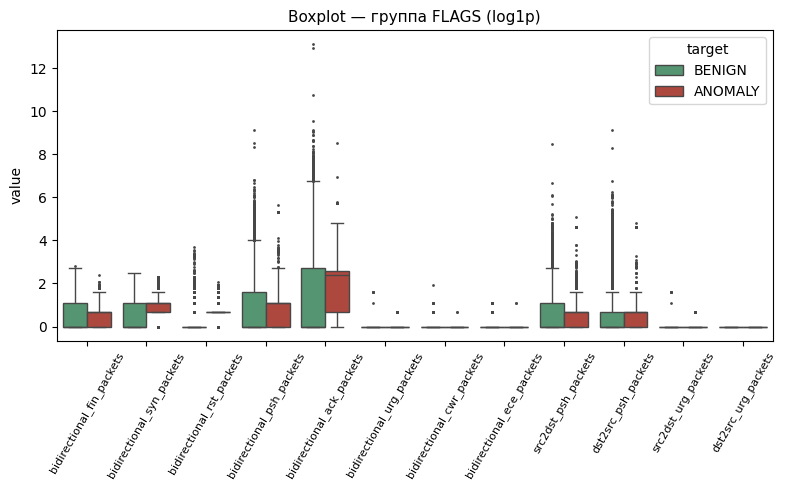

Saved: /workspace/results/figures/fig_02_boxplot_flags.png


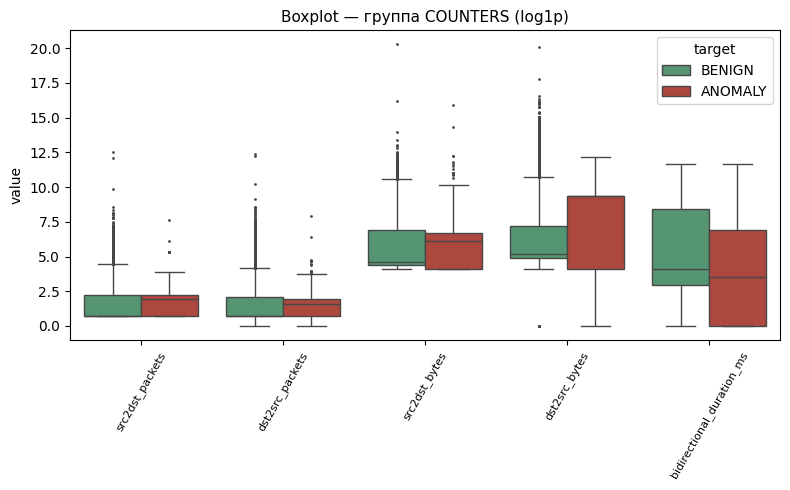

Saved: /workspace/results/figures/fig_02_boxplot_counters.png


In [9]:
def plot_box_group(df: pd.DataFrame, features: list[str],
                   group_name: str, use_log1p: bool,
                   sample_size: int = 200_000) -> None:
    rng = np.random.default_rng(RANDOM_STATE)
    n_per_class = sample_size // 2
    benign_idx = df.index[df["target"] == 0]
    anom_idx   = df.index[df["target"] == 1]
    bs = rng.choice(benign_idx, size=min(n_per_class, len(benign_idx)), replace=False)
    as_ = rng.choice(anom_idx,   size=min(n_per_class, len(anom_idx)),   replace=False)
    sample_idx = np.concatenate([bs, as_])
    sub = df.loc[sample_idx, features + ["target"]].copy()
    if use_log1p:
        for c in features:
            sub[c] = np.log1p(np.clip(sub[c].astype("float64"), 0, None))

    long = sub.melt(id_vars="target", var_name="feature", value_name="value")
    long["target"] = long["target"].map({0: "BENIGN", 1: "ANOMALY"})

    fig, ax = plt.subplots(figsize=(max(8, 0.55 * len(features)), 5))
    sns.boxplot(data=long, x="feature", y="value", hue="target",
                palette={"BENIGN": "#4C9F70", "ANOMALY": "#C0392B"},
                fliersize=1, ax=ax)
    ax.set_title(f"Boxplot — группа {group_name}"
                 f"{' (log1p)' if use_log1p else ''}", fontsize=11)
    ax.tick_params(axis="x", rotation=60, labelsize=8)
    ax.set_xlabel("")
    plt.tight_layout()
    out = FIG_DIR / f"fig_02_boxplot_{group_name.lower()}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

plot_box_group(df, FEAT_PS,    "PS",       use_log1p=True)
plot_box_group(df, FEAT_PIAT,  "PIAT",     use_log1p=True)
plot_box_group(df, FEAT_FLAGS, "FLAGS",    use_log1p=True)  # флаги тоже тяжелые
plot_box_group(df, FEAT_COUNT, "COUNTERS", use_log1p=True)

## 3. Корреялции каждого признака с target

Корреляции по таргету считаются по:
- **К. Пирсона** (линейный)
- **Spearman** (ранговый, устойчив к выбросам) 

**Spearman** обычно информативнее - в данных много тяжелых хвостов, а К.Пирсона чувствителен к выбросам.

Сэмплюруются 500,000 строк со стратификацией.

In [10]:
# Стратифицированный сэмпл для скорости
def stratified_sample(df: pd.DataFrame, size: int) -> pd.DataFrame:
    rng = np.random.default_rng(RANDOM_STATE)
    n_per = size // 2
    bs = rng.choice(df.index[df["target"] == 0],
                    size=min(n_per, (df["target"] == 0).sum()), replace=False)
    as_ = rng.choice(df.index[df["target"] == 1],
                     size=min(n_per, (df["target"] == 1).sum()), replace=False)
    return df.loc[np.concatenate([bs, as_])]

sub = stratified_sample(df, 500_000)
print(f"Стратифицированный сэмпл: {len(sub):,}")

rows = []
for c in MODEL_FEATURES:
    x = sub[c].astype("float64").to_numpy()
    y = sub["target"].astype("float64").to_numpy()
    # Пирсон — np.corrcoef
    pearson = float(np.corrcoef(x, y)[0, 1])
    # Спирмен — scipy
    rho, _ = spearmanr(x, y)
    rows.append({"feature": c, "pearson": pearson, "spearman": float(rho)})

corr_target = pd.DataFrame(rows)
corr_target["abs_spearman"] = corr_target["spearman"].abs()
corr_target = corr_target.sort_values("abs_spearman", ascending=False).reset_index(drop=True)
corr_target.to_csv(TAB_DIR / "eda_feature_target_correlation.csv", index=False)
print(f"Saved: {TAB_DIR / 'eda_feature_target_correlation.csv'}")
corr_target.head(20)

Стратифицированный сэмпл: 500,000
Saved: /workspace/results/tables/eda_feature_target_correlation.csv


,feature,pearson,spearman,abs_spearman
0,bidirectional_rst_packets,0.547424,0.769421,0.769421
1,protocol,-0.682101,-0.682101,0.682101
2,bidirectional_min_ps,-0.490372,-0.651540,0.651540
3,dst2src_min_ps,-0.507713,-0.585635,0.585635
4,src2dst_min_ps,-0.266351,-0.534208,0.534208
5,bidirectional_min_piat_ms,-0.085822,-0.508780,0.508780
6,bidirectional_syn_packets,0.481293,0.489212,0.489212
7,dst2src_stddev_ps,0.483946,0.340047,0.340047
8,src2dst_mean_ps,-0.039210,-0.324564,0.324564
9,bidirectional_ack_packets,-0.006015,0.308251,0.308251


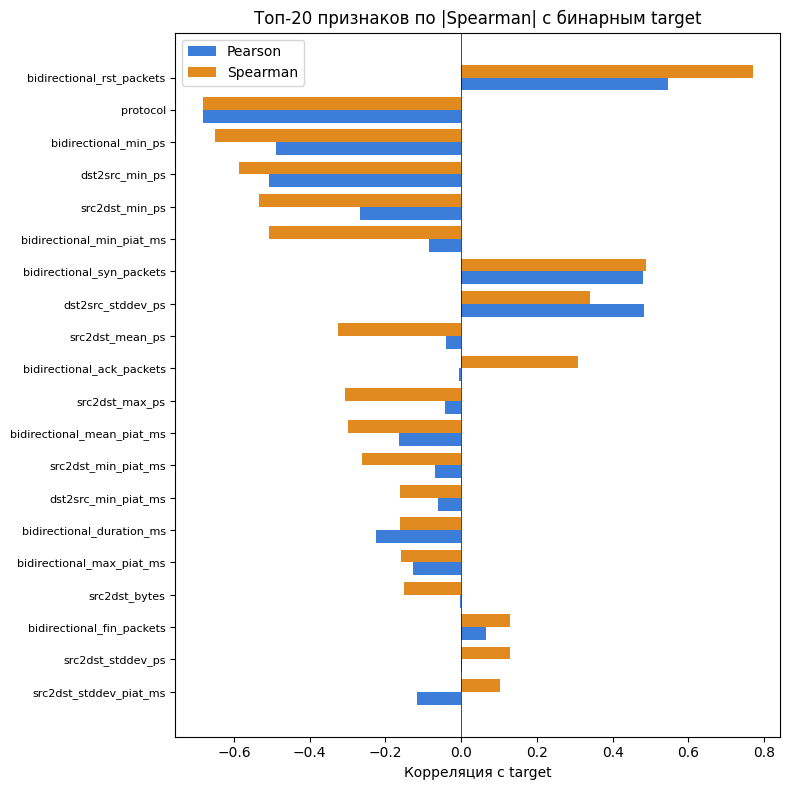

Saved: /workspace/results/figures/fig_02_top_corr_with_target.png


In [11]:
top_n = 20
top = corr_target.head(top_n).iloc[::-1]  # переворот дял читаймости

fig, ax = plt.subplots(figsize=(8, 0.35 * top_n + 1))
y_pos = np.arange(len(top))
ax.barh(y_pos - 0.2, top["pearson"],  height=0.4, label="Pearson",  color="#3B7DD8")
ax.barh(y_pos + 0.2, top["spearman"], height=0.4, label="Spearman", color="#E08A1F")
ax.set_yticks(y_pos)
ax.set_yticklabels(top["feature"], fontsize=8)
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("Корреляция с target")
ax.set_title(f"Топ-{top_n} признаков по |Spearman| с бинарным target")
ax.legend()
plt.tight_layout()
out = FIG_DIR / "fig_02_top_corr_with_target.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

## 4. Корреляции между признаками

Корреляционная матрица 42x42 (Spearman на стратифицированном сэмпле).

**Цель**: найти группы взаимозависимых признаков, и мультиколлениарность

Saved: /workspace/results/tables/eda_feature_feature_correlation.csv


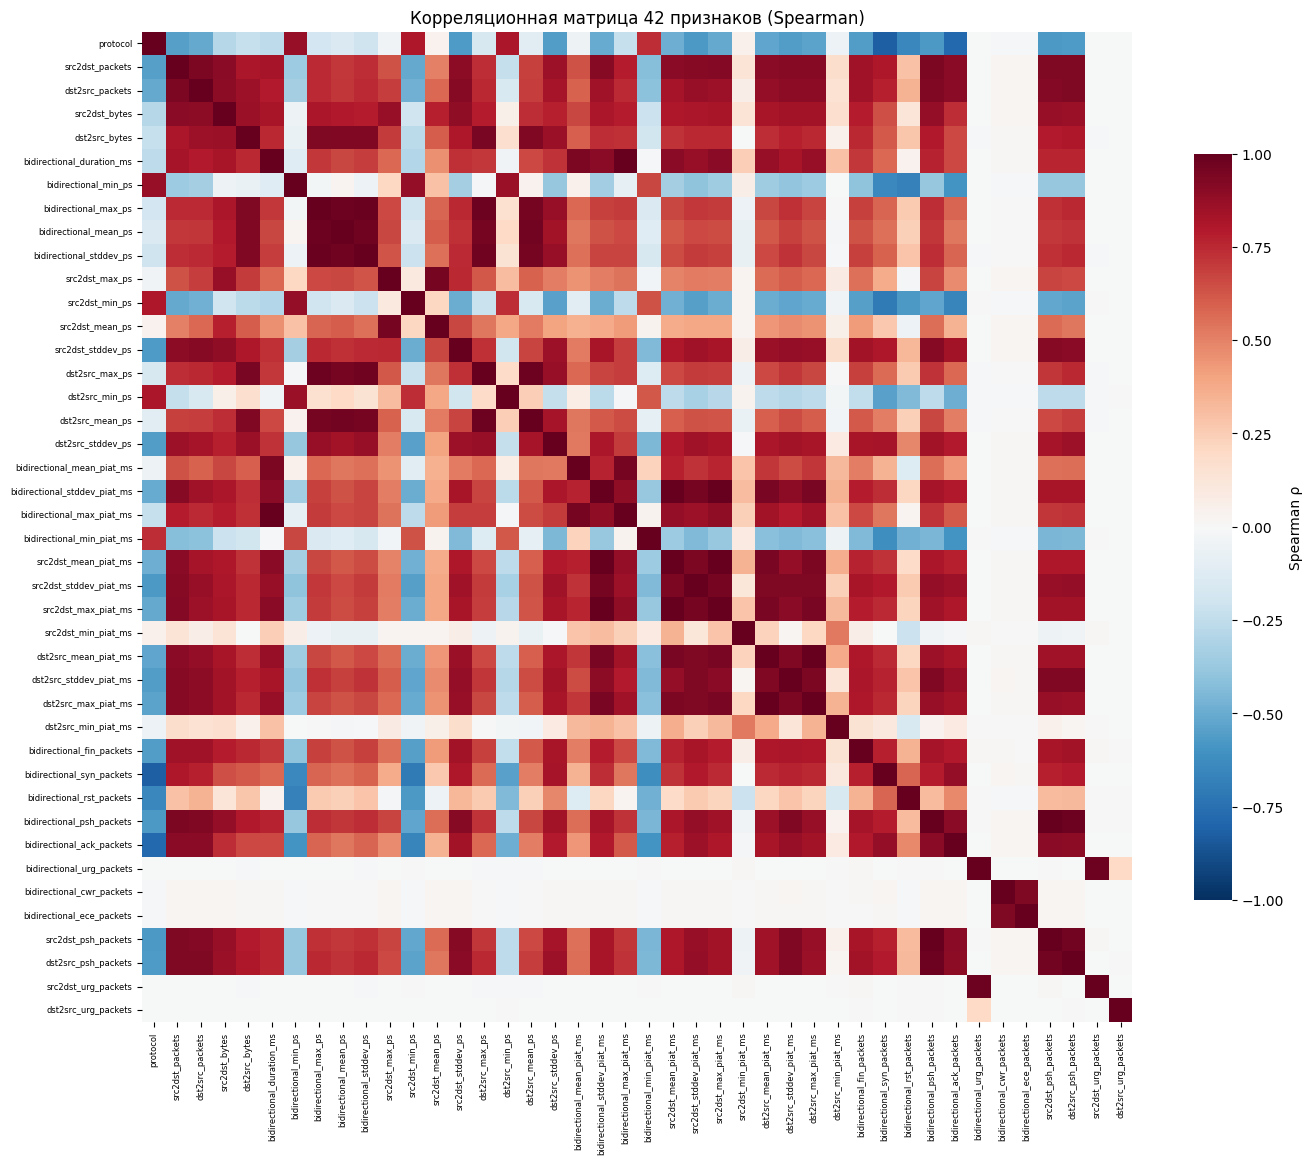

Saved: /workspace/results/figures/fig_02_corr_features.png


In [12]:
sub_feat = sub[MODEL_FEATURES].astype("float64")
corr_mat = sub_feat.corr(method="spearman")
corr_mat.to_csv(TAB_DIR / "eda_feature_feature_correlation.csv")
print(f"Saved: {TAB_DIR / 'eda_feature_feature_correlation.csv'}")

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_mat, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.7, "label": "Spearman ρ"},
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_title("Корреляционная матрица 42 признаков (Spearman)", fontsize=12)
ax.tick_params(axis="x", labelsize=6, rotation=90)
ax.tick_params(axis="y", labelsize=6)
plt.tight_layout()
out = FIG_DIR / "fig_02_corr_features.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

In [13]:
import itertools

high_corr_pairs = []
for i, j in itertools.combinations(range(len(MODEL_FEATURES)), 2):
    a, b = MODEL_FEATURES[i], MODEL_FEATURES[j]
    r = corr_mat.iloc[i, j]
    if abs(r) > 0.95:
        high_corr_pairs.append({"feat_a": a, "feat_b": b, "spearman": round(r, 4)})

pairs_df = pd.DataFrame(high_corr_pairs).sort_values("spearman", key=abs, ascending=False)
pairs_df.to_csv(TAB_DIR / "eda_high_corr_pairs.csv", index=False)
print(f"Пар с |Spearman| > 0.95: {len(pairs_df)}")
print(f"Saved: {TAB_DIR / 'eda_high_corr_pairs.csv'}")
pairs_df

Пар с |Spearman| > 0.95: 26
Saved: /workspace/results/tables/eda_high_corr_pairs.csv


,feat_a,feat_b,spearman
22,bidirectional_psh_packets,src2dst_psh_packets,0.9963
21,dst2src_mean_piat_ms,dst2src_max_piat_ms,0.9962
15,bidirectional_stddev_piat_ms,src2dst_max_piat_ms,0.9954
13,bidirectional_stddev_piat_ms,src2dst_mean_piat_ms,0.9946
18,src2dst_mean_piat_ms,src2dst_max_piat_ms,0.9931
0,bidirectional_duration_ms,bidirectional_max_piat_ms,0.9923
2,bidirectional_max_ps,bidirectional_stddev_ps,0.9918
11,dst2src_max_ps,dst2src_mean_ps,0.9814
3,bidirectional_max_ps,dst2src_max_ps,0.9811
24,bidirectional_urg_packets,src2dst_urg_packets,0.9806


## 5. Диаграммы рассеивания топ-4 признаков по корреляции с таргетом

Топ-4 признака: ['bidirectional_rst_packets', 'protocol', 'bidirectional_min_ps', 'dst2src_min_ps']


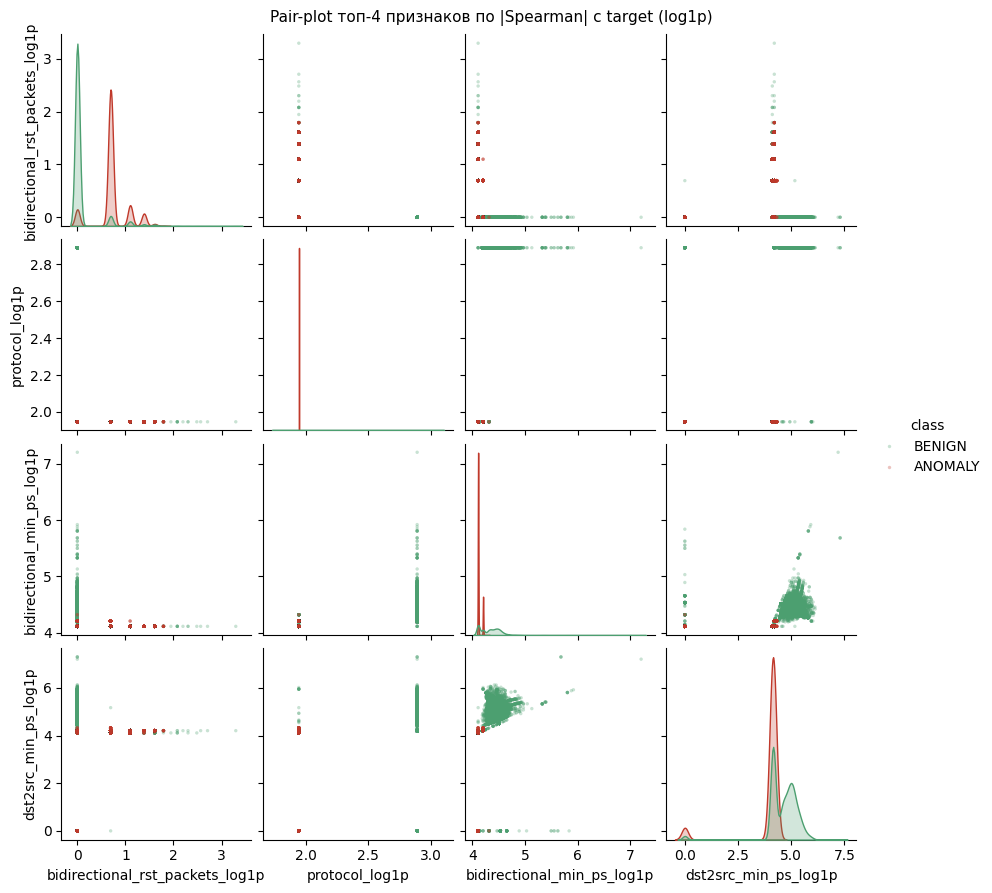

Saved: /workspace/results/figures/fig_02_pairs_top4.png


In [14]:
top4 = corr_target.head(4)["feature"].tolist()
print("Топ-4 признака:", top4)

rng = np.random.default_rng(RANDOM_STATE)
n_per = 10_000
bs = rng.choice(df.index[df["target"] == 0], size=n_per, replace=False)
as_ = rng.choice(df.index[df["target"] == 1], size=n_per, replace=False)
sub_pp = df.loc[np.concatenate([bs, as_]), top4 + ["target"]].copy()
sub_pp["class"] = sub_pp["target"].map({0: "BENIGN", 1: "ANOMALY"})

# log1p трансформация
for c in top4:
    sub_pp[c + "_log1p"] = np.log1p(np.clip(sub_pp[c].astype("float64"), 0, None))

g = sns.pairplot(
    sub_pp,
    vars=[c + "_log1p" for c in top4],
    hue="class",
    palette={"BENIGN": "#4C9F70", "ANOMALY": "#C0392B"},
    plot_kws={"s": 6, "alpha": 0.3, "edgecolor": "none"},
    diag_kind="kde",
    height=2.2,
)
g.fig.suptitle("Pair-plot топ-4 признаков по |Spearman| с target (log1p)",
               y=1.01, fontsize=11)
out = FIG_DIR / "fig_02_pairs_top4.png"
g.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out}")

# Итоги исследования

### 1) Топ-7 признаков по корреляции с таргетом

| ранг | признак                       | Spearman | Pearson | комментарий                       |
|------|-------------------------------|---------:|--------:|-----------------------------------|
| 1    | `bidirectional_rst_packets`   | +0.77    | +0.54   | RST массово генерируют PortScan/DoS/DDoS |
| 2    | `protocol`                    | -0.66    | -0.69   | UDP/ICMP-flow реже атаки в CICIDS-2017 |
| 3    | `bidirectional_min_ps`        | -0.55    | -0.46   | у атак типично малые минимальные пакеты |
| 4    | `dst2src_min_ps`              | -0.55    | -0.50   | то же со стороны жертвы           |
| 5    | `src2dst_min_ps`              | -0.50    | -0.51   | то же со стороны атакующего       |
| 6    | `bidirectional_min_piat_ms`   | -0.50    | -0.08   | резкое расхождение Pearson↔Spearman -> нелинейная связь |
| 7    | `bidirectional_syn_packets`   | +0.45    | +0.48   | линейный сигнал: больше SYN -> выше шанс атаки |

### 2) Линейные vs нелинейные связи
tree-based (RF/LightGBM) и нейросети будут эффективнее линейных (Naive Bayes, LogReg), потому что используют ранговую структуру признаков, а не Пирсон (линейную).

### 3) Доминирующий признак и риски плохого обобщения

- `bidirectional_rst_packets` со Spearman = +0.77 — фактически бинарный
индикатор аномалии: в большинстве flow с RST-пакетами это PortScan/DoS Hulk/DDoS,
а в BENIGN-flow RST он редко встречается.


### 4) Мультиколлинеарность: 26 пар с |Spearman| > 0.95, три плотных кластера


**(а) COUNTERS (5 колонок, mean внутрикластерная \|ρ\|=0.85).** `src2dst_packets`,
`dst2src_packets`, `src2dst_bytes`, `dst2src_bytes`, `bidirectional_duration_ms`.
Самые тесные: `src2dst_packets ↔ dst2src_packets` (0.94), `src2dst_packets ↔
src2dst_bytes` (0.91). Ожидаемо: число пакетов и переданных байт движутся вместе.

**(б) PS (12 колонок, mean=0.58, median=0.63).** Сильнейшие пары:
`bidirectional_max_ps ↔ bidirectional_stddev_ps` (0.992),
`bidirectional_max_ps ↔ dst2src_max_ps` (0.981),
`bidirectional_max_ps ↔ bidirectional_mean_ps` (0.978).
Bidirectional-агрегат — фактически взвешенная композиция src2dst+dst2src.

**(в) PIAT (12 колонок, mean=0.65, median=0.77 — самый плотный).** Сильнейшие:
`dst2src_mean_piat_ms ↔ dst2src_max_piat_ms` (0.996),
`bidirectional_stddev_piat_ms ↔ src2dst_max_piat_ms` (0.995),
`bidirectional_duration_ms ↔ bidirectional_max_piat_ms` (0.992).
Длинный flow по определению имеет большие inter-arrival.

**(г) Дублирующиеся флаги между направлениями.**
`bidirectional_psh_packets ↔ src2dst_psh_packets` (0.996),
`bidirectional_urg_packets ↔ src2dst_urg_packets` (0.981),
`bidirectional_cwr_packets ↔ bidirectional_ece_packets` (0.930).

Это не критично для tree-based моделей и нейросетей (они устойчивы к
коллинеарности)

### 5) `protocol` — категория, а не число

`protocol` показывает сильные ρ со многими признаками: ρ=+0.870 с
`bidirectional_min_ps`, ρ=-0.828 с `bidirectional_syn_packets`, ρ=+0.81 с
`dst2src_min_ps` и `src2dst_min_ps`, ρ=-0.787 с `bidirectional_ack_packets`.


Это артефакт того, что `protocol` принимает 2-3 значения кода
(6=TCP, 17=UDP, иногда 1=ICMP), и Spearman на 3-х значениях даёт высокую
ранговую связь по чисто протокольным различиям (UDP не имеет SYN/ACK).

- Нужно применять one-hot encoding

## 6) NaN/Inf/константные признаки


- Матрица 42×42 не содержит NaN

- Константных колонок, которые нужно было бы удалить по нулевой информативности, нет.
